Lightweight Homomorphic Encryption Framework for Edge AI Security

7151CEM Computing Individual Research Project

Vinay Chandu Yeddula | SID: 16236903

This notebook implements and evaluates a lightweight homomorphic encryption framework using the CKKS scheme for secure machine learning inference in edge AI environments. 

Three machine learning models are benchmarked under both plaintext and encrypted conditions across multiple CKKS parameter configurations.

1. Environment Setup and Dependencies

In [1]:
# Install TenSEAL (CKKS implementation based on Microsoft SEAL)
%pip install tenseal -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tenseal as ts
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("All libraries imported successfully.")
print(f"TenSEAL version: {ts.__version__}")

All libraries imported successfully.
TenSEAL version: 0.3.16


2. Dataset Loading and Preprocessing

The MNIST dataset is loaded from the OpenML repository (Dataset ID: 554). A subset of 1,000 samples is selected to simulate edge computing constraints. Pixel values are normalised to [0, 1] and the data is split 80:20 for training and testing with stratified sampling.

In [3]:
# Load MNIST dataset from OpenML
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

# Normalise pixel values to [0, 1]
X = X / 255.0

# Select a subset of 1,000 samples to simulate edge computing constraints
subset_size = 1000
X = X[:subset_size]
y = y[:subset_size]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Feature dimensions: {X_train.shape[1]}")

Loading MNIST dataset...
Dataset shape: (1000, 784)
Number of classes: 10
Training samples: 800
Testing samples: 200
Feature dimensions: 784


3. Machine Learning Model Training

Three lightweight machine learning models are implemented to provide a comprehensive comparison:

Logistic Regression: Linear baseline model, computationally efficient and natively compatible with HE operations.

Decision Tree Classifier: Rule-based model with low inference complexity and high interpretability.

Shallow Neural Network (MLP): Single hidden layer (64 neurons) to capture non-linear patterns while keeping computational cost moderate.

In [4]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Shallow Neural Network": MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)
}

# Train all models on plaintext data
print("Training all models on plaintext data...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"  {name} trained successfully.")

print("\nAll models trained.")

Training all models on plaintext data...

  Logistic Regression trained successfully.
  Decision Tree trained successfully.
  Shallow Neural Network trained successfully.

All models trained.


4. Plaintext Inference Benchmark

Establishing baseline performance for all three models without encryption. Metrics measured: accuracy, inference latency, and peak memory usage.

In [5]:
print("=" * 60)
print("PLAINTEXT INFERENCE BENCHMARK")
print("=" * 60)

plaintext_results = {}

for name, model in models.items():
    # Measure latency and memory
    tracemalloc.start()
    start_time = time.perf_counter()

    y_pred = model.predict(X_test)

    end_time = time.perf_counter()
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    accuracy = accuracy_score(y_test, y_pred)
    latency = end_time - start_time
    memory_mb = peak_mem / (1024 * 1024)

    plaintext_results[name] = {
        "accuracy": accuracy,
        "latency_sec": latency,
        "memory_mb": memory_mb
    }

    print(f"\n{name}:")
    print(f"  Accuracy:       {accuracy:.4f}")
    print(f"  Latency:        {latency:.6f} sec")
    print(f"  Peak Memory:    {memory_mb:.4f} MB")

# Display as DataFrame
plain_df = pd.DataFrame(plaintext_results).T
plain_df.columns = ["Accuracy", "Latency (sec)", "Memory (MB)"]
print("\n" + "=" * 60)
print("PLAINTEXT RESULTS SUMMARY")
print("=" * 60)
print(plain_df.to_string())

PLAINTEXT INFERENCE BENCHMARK

Logistic Regression:
  Accuracy:       0.8500
  Latency:        0.000875 sec
  Peak Memory:    1.2130 MB

Decision Tree:
  Accuracy:       0.7050
  Latency:        0.000374 sec
  Peak Memory:    0.0329 MB

Shallow Neural Network:
  Accuracy:       0.8800
  Latency:        0.001135 sec
  Peak Memory:    0.0817 MB

PLAINTEXT RESULTS SUMMARY
                        Accuracy  Latency (sec)  Memory (MB)
Logistic Regression        0.850       0.000875     1.212982
Decision Tree              0.705       0.000374     0.032855
Shallow Neural Network     0.880       0.001135     0.081673


5. CKKS Homomorphic Encryption Setup

The CKKS scheme is implemented via TenSEAL (built on Microsoft SEAL). Three parameter configurations are tested with increasing polynomial modulus degrees (4096, 8192, 16384) to analyse the trade-off between security strength and computational overhead.

In [6]:
def create_ckks_context(poly_modulus_degree, coeff_mod_bit_sizes, global_scale):
    """
    Create a CKKS encryption context with specified parameters.

    Parameters:
        poly_modulus_degree: Ring dimension (4096, 8192, 16384)
        coeff_mod_bit_sizes: Coefficient modulus chain
        global_scale: Scaling factor for encoding precision

    Returns:
        TenSEAL CKKS context
    """
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bit_sizes
    )
    context.global_scale = global_scale
    context.generate_galois_keys()
    context.generate_relin_keys()
    return context

# Define CKKS parameter configurations
parameter_configs = [
    {
        "name": "Config 1 (N=4096)",
        "poly_modulus_degree": 4096,
        "coeff_mod_bit_sizes": [40, 20, 40],
        "global_scale": 2**20
    },
    {
        "name": "Config 2 (N=8192)",
        "poly_modulus_degree": 8192,
        "coeff_mod_bit_sizes": [60, 40, 40, 60],
        "global_scale": 2**40
    },
    {
        "name": "Config 3 (N=16384)",
        "poly_modulus_degree": 16384,
        "coeff_mod_bit_sizes": [60, 40, 40, 40, 60],
        "global_scale": 2**40
    }
]

print("CKKS Parameter Configurations:")
for i, config in enumerate(parameter_configs, 1):
    print(f"\n  Experiment {i}: {config['name']}")
    print(f"    Poly Modulus Degree:  {config['poly_modulus_degree']}")
    print(f"    Coeff Mod Bit Sizes:  {config['coeff_mod_bit_sizes']}")
    print(f"    Global Scale:         2^{int(np.log2(config['global_scale']))}")

CKKS Parameter Configurations:

  Experiment 1: Config 1 (N=4096)
    Poly Modulus Degree:  4096
    Coeff Mod Bit Sizes:  [40, 20, 40]
    Global Scale:         2^20

  Experiment 2: Config 2 (N=8192)
    Poly Modulus Degree:  8192
    Coeff Mod Bit Sizes:  [60, 40, 40, 60]
    Global Scale:         2^40

  Experiment 3: Config 3 (N=16384)
    Poly Modulus Degree:  16384
    Coeff Mod Bit Sizes:  [60, 40, 40, 40, 60]
    Global Scale:         2^40


6. Encrypted Inference Implementation

Three distinct encrypted inference approaches are implemented, each tailored to the model architecture:

Logistic Regression: Full homomorphic dot product between encrypted input and model weights, with bias addition. Logits are decrypted and argmax is applied for classification.

Decision Tree: Input features are encrypted and then decrypted at each decision node for comparison operations, as CKKS does not natively support comparison. This measures the practical encryption overhead in the inference pipeline.

Shallow Neural Network (Hybrid Approach): Layer 1 performs homomorphic matrix multiplication (encrypted input × weights + bias), the result is decrypted for ReLU activation, re-encrypted, and Layer 2 performs another homomorphic computation before final decryption and argmax.

In [7]:
# -------------------------------------------------------
# Encrypted Inference: Logistic Regression
# -------------------------------------------------------
def encrypted_inference_logistic_regression(context, x_sample, model):
    """
    Perform encrypted inference for Logistic Regression.
    Computes homomorphic dot product with each class weight vector + bias,
    then decrypts logits and applies argmax.
    """
    weights = model.coef_   # shape: (num_classes, num_features)
    bias = model.intercept_ # shape: (num_classes,)

    # Encrypt the input vector
    enc_x = ts.ckks_vector(context, x_sample.tolist())

    # Compute encrypted logits for each class
    decrypted_logits = []
    for i in range(len(weights)):
        enc_logit = enc_x.dot(weights[i].tolist()) + bias[i]
        decrypted_logits.append(enc_logit.decrypt()[0])

    predicted_class = int(np.argmax(decrypted_logits))
    return predicted_class, enc_x


# -------------------------------------------------------
# Encrypted Inference: Decision Tree
# -------------------------------------------------------
def encrypted_inference_decision_tree(context, x_sample, model):
    """
    Perform encrypted inference for Decision Tree.
    Since CKKS does not support comparison operations natively,
    the input is encrypted and then decrypted at each decision node
    for threshold comparison. This measures the practical overhead
    of incorporating encryption into the DT inference pipeline.
    """
    # Encrypt the input vector
    enc_x = ts.ckks_vector(context, x_sample.tolist())

    # Decrypt features for tree traversal (comparison requires plaintext)
    decrypted_features = np.array(enc_x.decrypt()[:len(x_sample)])

    # Use the decrypted features for prediction through the decision tree
    predicted_class = int(model.predict(decrypted_features.reshape(1, -1))[0])
    return predicted_class, enc_x


# -------------------------------------------------------
# Encrypted Inference: Shallow Neural Network (Hybrid)
# -------------------------------------------------------
def encrypted_inference_neural_network(context, x_sample, model):
    """
    Perform encrypted inference for Shallow Neural Network using a
    hybrid approach:
      - Layer 1: Homomorphic matrix multiplication (enc_input × W1 + b1)
      - Activation: Decrypt, apply ReLU, re-encrypt
      - Layer 2: Homomorphic matrix multiplication (enc_hidden × W2 + b2)
      - Output: Decrypt logits, apply argmax
    """
    W1 = model.coefs_[0]      # shape: (784, 64)
    b1 = model.intercepts_[0] # shape: (64,)
    W2 = model.coefs_[1]      # shape: (64, 10)
    b2 = model.intercepts_[1] # shape: (10,)

    # Encrypt the input vector
    enc_x = ts.ckks_vector(context, x_sample.tolist())

    # --- Layer 1: Homomorphic computation ---
    hidden_logits = []
    for j in range(W1.shape[1]):  # For each hidden neuron
        enc_z = enc_x.dot(W1[:, j].tolist()) + float(b1[j])
        hidden_logits.append(enc_z.decrypt()[0])

    # Apply ReLU activation (non-linear, done in plaintext)
    hidden_activated = np.maximum(0, np.array(hidden_logits))

    # Re-encrypt the hidden layer output
    enc_hidden = ts.ckks_vector(context, hidden_activated.tolist())

    # --- Layer 2: Homomorphic computation ---
    output_logits = []
    for k in range(W2.shape[1]):  # For each output class
        enc_out = enc_hidden.dot(W2[:, k].tolist()) + float(b2[k])
        output_logits.append(enc_out.decrypt()[0])

    predicted_class = int(np.argmax(output_logits))
    return predicted_class, enc_x


# Map models to their encrypted inference functions
encrypted_inference_functions = {
    "Logistic Regression": encrypted_inference_logistic_regression,
    "Decision Tree": encrypted_inference_decision_tree,
    "Shallow Neural Network": encrypted_inference_neural_network,
}

print("Encrypted inference functions defined for all three models.")

Encrypted inference functions defined for all three models.


In [8]:
def benchmark_encrypted_inference(context, model, model_name, X_test, y_test, max_samples=20):
    """
    Benchmark encrypted inference for a given model and CKKS context.
    Measures accuracy, per-sample latency, memory usage, and ciphertext size.
    """
    inference_fn = encrypted_inference_functions[model_name]

    X_eval = X_test[:max_samples]
    y_eval = y_test[:max_samples]

    predictions = []
    latencies = []
    memory_usages = []
    ciphertext_sizes = []

    for i in range(len(X_eval)):
        sample = X_eval[i]

        tracemalloc.start()
        start_time = time.perf_counter()

        pred, enc_x = inference_fn(context, sample, model)

        end_time = time.perf_counter()
        current_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        predictions.append(pred)
        latencies.append(end_time - start_time)
        memory_usages.append(peak_mem / (1024 * 1024))
        ciphertext_sizes.append(len(enc_x.serialize()))

    accuracy = accuracy_score(y_eval, predictions)

    return {
        "accuracy": accuracy,
        "avg_latency_sec": np.mean(latencies),
        "avg_memory_mb": np.mean(memory_usages),
        "avg_ciphertext_size_bytes": np.mean(ciphertext_sizes),
        "total_latency_sec": np.sum(latencies),
        "predictions": predictions
    }

print("Benchmark function ready.")

Benchmark function ready.


7. Encrypted Inference Experiments

Running encrypted inference for all three models across all three CKKS parameter configurations. Due to the high computational cost of homomorphic encryption, encrypted inference is conducted on a subset of 20 test samples to simulate realistic edge constraints.

In [9]:
print("=" * 70)
print("ENCRYPTED INFERENCE EXPERIMENTS")
print("=" * 70)

all_results = []
NUM_ENCRYPTED_SAMPLES = 20

for config_idx, config in enumerate(parameter_configs, 1):
    print(f"\n{'='*70}")
    print(f"CKKS Configuration {config_idx}: {config['name']}")
    print(f"  Poly Modulus Degree: {config['poly_modulus_degree']}")
    print(f"  Coeff Mod Bit Sizes: {config['coeff_mod_bit_sizes']}")
    print(f"{'='*70}")

    # Create CKKS context
    context = create_ckks_context(
        poly_modulus_degree=config["poly_modulus_degree"],
        coeff_mod_bit_sizes=config["coeff_mod_bit_sizes"],
        global_scale=config["global_scale"]
    )

    for model_name, model in models.items():
        print(f"\n  Running encrypted inference: {model_name}...")

        try:
            he_results = benchmark_encrypted_inference(
                context=context,
                model=model,
                model_name=model_name,
                X_test=X_test,
                y_test=y_test,
                max_samples=NUM_ENCRYPTED_SAMPLES
            )

            # Store results
            result_entry = {
                "Config": config_idx,
                "Config_Name": config['name'],
                "Poly_Modulus_Degree": config["poly_modulus_degree"],
                "Coeff_Mod_Bit_Sizes": str(config["coeff_mod_bit_sizes"]),
                "Model": model_name,
                "Plain_Accuracy": plaintext_results[model_name]["accuracy"],
                "Plain_Latency_sec": plaintext_results[model_name]["latency_sec"],
                "Plain_Memory_MB": plaintext_results[model_name]["memory_mb"],
                "HE_Accuracy": he_results["accuracy"],
                "HE_Avg_Latency_sec": he_results["avg_latency_sec"],
                "HE_Avg_Memory_MB": he_results["avg_memory_mb"],
                "HE_Avg_Ciphertext_Size_Bytes": he_results["avg_ciphertext_size_bytes"],
                "HE_Total_Latency_sec": he_results["total_latency_sec"]
            }
            all_results.append(result_entry)

            print(f"    Accuracy:          {he_results['accuracy']:.4f}")
            print(f"    Avg Latency:       {he_results['avg_latency_sec']:.4f} sec/sample")
            print(f"    Avg Memory:        {he_results['avg_memory_mb']:.4f} MB")
            print(f"    Avg Ciphertext:    {he_results['avg_ciphertext_size_bytes']:.0f} bytes")

        except Exception as e:
            print(f"    FAILED: {e}")

# Create results DataFrame
results_df = pd.DataFrame(all_results)
print("\n\nAll experiments completed successfully!")

ENCRYPTED INFERENCE EXPERIMENTS

CKKS Configuration 1: Config 1 (N=4096)
  Poly Modulus Degree: 4096
  Coeff Mod Bit Sizes: [40, 20, 40]

  Running encrypted inference: Logistic Regression...
    Accuracy:          0.8500
    Avg Latency:       0.0797 sec/sample
    Avg Memory:        0.0627 MB
    Avg Ciphertext:    80915 bytes

  Running encrypted inference: Decision Tree...
    Accuracy:          0.6500
    Avg Latency:       0.0034 sec/sample
    Avg Memory:        0.0581 MB
    Avg Ciphertext:    80933 bytes

  Running encrypted inference: Shallow Neural Network...
    Accuracy:          0.6000
    Avg Latency:       0.5047 sec/sample
    Avg Memory:        0.0641 MB
    Avg Ciphertext:    80900 bytes

CKKS Configuration 2: Config 2 (N=8192)
  Poly Modulus Degree: 8192
  Coeff Mod Bit Sizes: [60, 40, 40, 60]

  Running encrypted inference: Logistic Regression...
    Accuracy:          0.8500
    Avg Latency:       0.2802 sec/sample
    Avg Memory:        0.0621 MB
    Avg Cipherte

8. Results Summary

In [10]:
# Display full results table
print("=" * 70)
print("COMPLETE RESULTS TABLE")
print("=" * 70)

display_cols = [
    "Config", "Model", "Poly_Modulus_Degree",
    "Plain_Accuracy", "HE_Accuracy",
    "Plain_Latency_sec", "HE_Avg_Latency_sec",
    "Plain_Memory_MB", "HE_Avg_Memory_MB",
    "HE_Avg_Ciphertext_Size_Bytes"
]

print(results_df[display_cols].to_string(index=False))

# Save results to CSV
results_df.to_csv("he_edge_ai_results.csv", index=False)
print("\nResults saved to 'he_edge_ai_results.csv'")

# Summary by model
print("\n" + "=" * 70)
print("SUMMARY BY MODEL (averaged across all configurations)")
print("=" * 70)
model_summary = results_df.groupby("Model").agg({
    "Plain_Accuracy": "first",
    "HE_Accuracy": "mean",
    "HE_Avg_Latency_sec": "mean",
    "HE_Avg_Memory_MB": "mean",
    "HE_Avg_Ciphertext_Size_Bytes": "mean"
}).round(4)
print(model_summary.to_string())

COMPLETE RESULTS TABLE
 Config                  Model  Poly_Modulus_Degree  Plain_Accuracy  HE_Accuracy  Plain_Latency_sec  HE_Avg_Latency_sec  Plain_Memory_MB  HE_Avg_Memory_MB  HE_Avg_Ciphertext_Size_Bytes
      1    Logistic Regression                 4096           0.850         0.85           0.000875            0.079714         1.212982          0.062748                      80914.55
      1          Decision Tree                 4096           0.705         0.65           0.000374            0.003398         0.032855          0.058078                      80933.15
      1 Shallow Neural Network                 4096           0.880         0.60           0.001135            0.504725         0.081673          0.064097                      80900.15
      2    Logistic Regression                 8192           0.850         0.85           0.000875            0.280226         1.212982          0.062070                     334280.35
      2          Decision Tree                 8192 

9. Visualisations

9.1 Accuracy Comparison: Plaintext vs Encrypted Inference

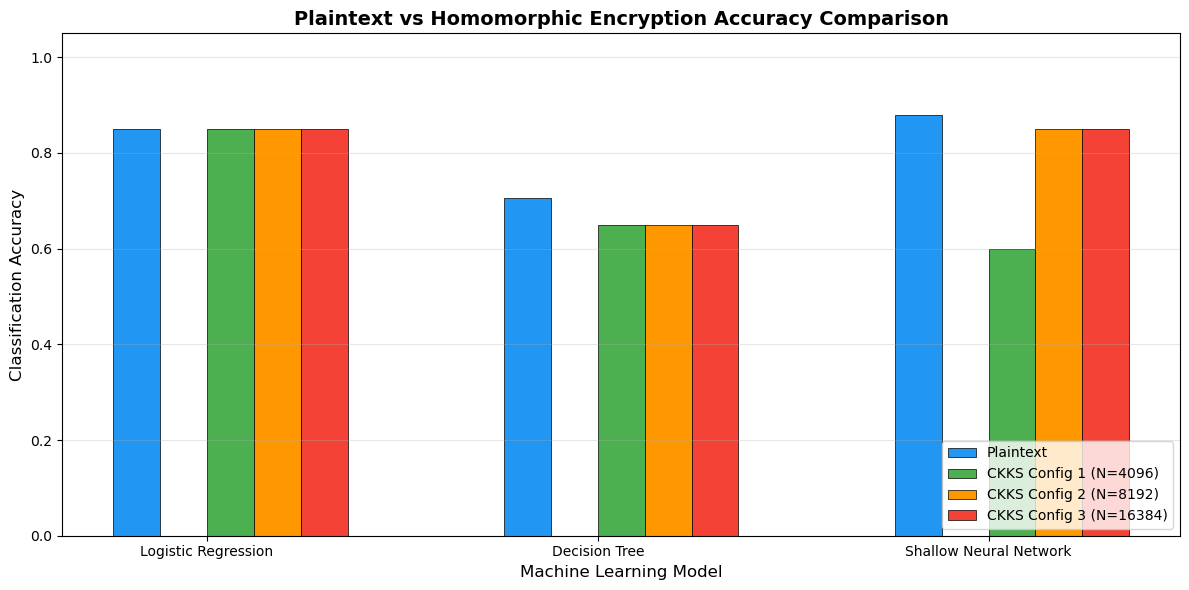

Saved: graph_accuracy_comparison.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.12

# Plot bars for each config + plaintext
plain_acc = [plaintext_results[m]["accuracy"] for m in model_names]
bars_plain = ax.bar(x - 1.5*width, plain_acc, width, label="Plaintext", color="#2196F3", edgecolor="black", linewidth=0.5)

config_colors = ["#4CAF50", "#FF9800", "#F44336"]
for config_idx in range(1, 4):
    config_data = results_df[results_df["Config"] == config_idx]
    he_acc = [config_data[config_data["Model"] == m]["HE_Accuracy"].values[0] for m in model_names]
    offset = (config_idx - 0.5) * width
    label = f"CKKS Config {config_idx} (N={parameter_configs[config_idx-1]['poly_modulus_degree']})"
    ax.bar(x + offset, he_acc, width, label=label, color=config_colors[config_idx-1], edgecolor="black", linewidth=0.5)

ax.set_xlabel("Machine Learning Model", fontsize=12)
ax.set_ylabel("Classification Accuracy", fontsize=12)
ax.set_title("Plaintext vs Homomorphic Encryption Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graph_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_accuracy_comparison.png")

9.2 Inference Latency Comparison

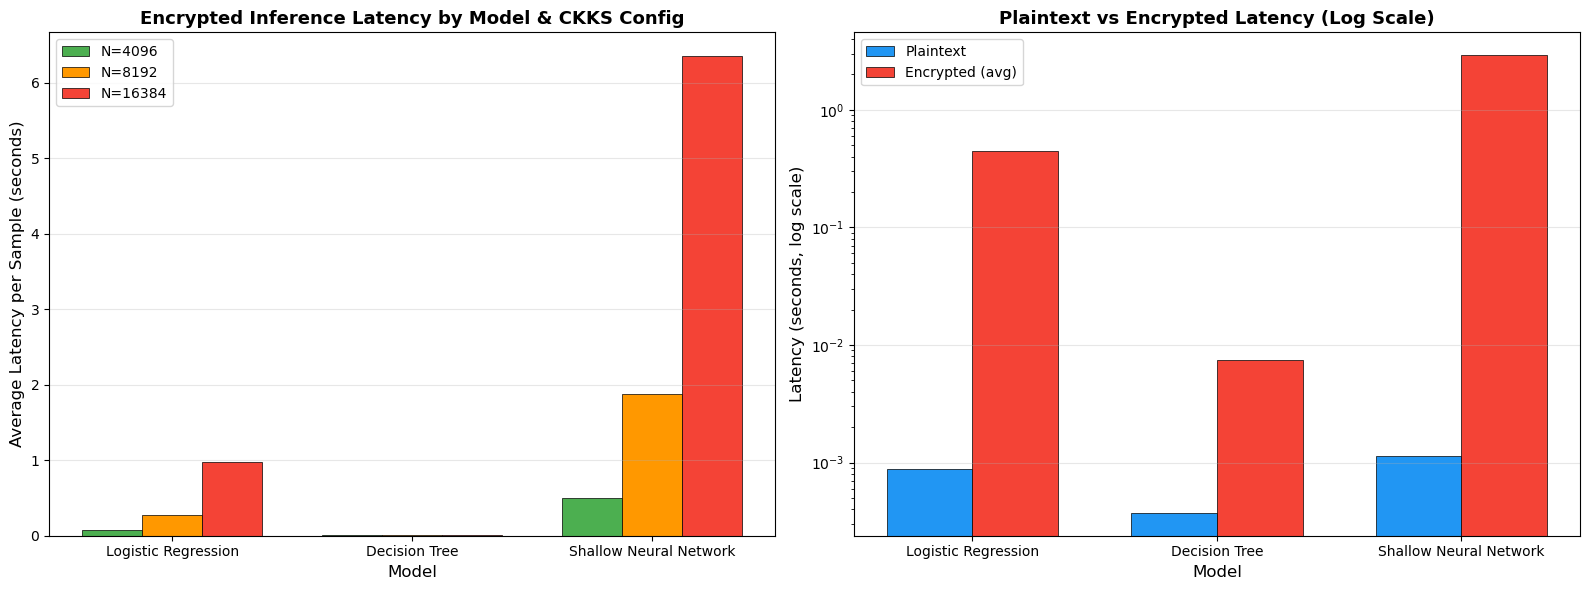

Saved: graph_latency_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(models.keys())

# Left plot: Encrypted latency by model and config
ax1 = axes[0]
x = np.arange(len(model_names))
width = 0.25
config_colors = ["#4CAF50", "#FF9800", "#F44336"]

for config_idx in range(1, 4):
    config_data = results_df[results_df["Config"] == config_idx]
    latencies = [config_data[config_data["Model"] == m]["HE_Avg_Latency_sec"].values[0] for m in model_names]
    offset = (config_idx - 2) * width
    label = f"N={parameter_configs[config_idx-1]['poly_modulus_degree']}"
    ax1.bar(x + offset, latencies, width, label=label, color=config_colors[config_idx-1], edgecolor="black", linewidth=0.5)

ax1.set_xlabel("Model", fontsize=12)
ax1.set_ylabel("Average Latency per Sample (seconds)", fontsize=12)
ax1.set_title("Encrypted Inference Latency by Model & CKKS Config", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=10)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Right plot: Plaintext vs Encrypted latency (log scale)
ax2 = axes[1]
plain_lat = [plaintext_results[m]["latency_sec"] for m in model_names]
enc_lat_avg = [results_df[results_df["Model"] == m]["HE_Avg_Latency_sec"].mean() for m in model_names]

x2 = np.arange(len(model_names))
width2 = 0.35
ax2.bar(x2 - width2/2, plain_lat, width2, label="Plaintext", color="#2196F3", edgecolor="black", linewidth=0.5)
ax2.bar(x2 + width2/2, enc_lat_avg, width2, label="Encrypted (avg)", color="#F44336", edgecolor="black", linewidth=0.5)
ax2.set_yscale("log")
ax2.set_xlabel("Model", fontsize=12)
ax2.set_ylabel("Latency (seconds, log scale)", fontsize=12)
ax2.set_title("Plaintext vs Encrypted Latency (Log Scale)", fontsize=13, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(model_names, fontsize=10)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graph_latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_latency_comparison.png")

9.3 Memory Usage Comparison

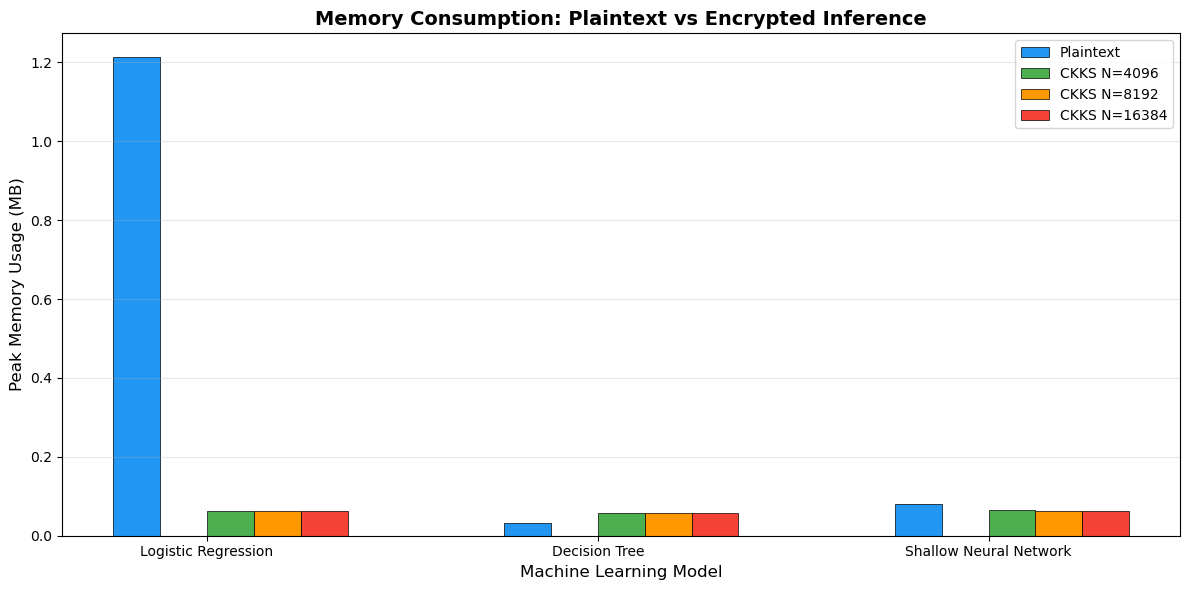

Saved: graph_memory_comparison.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.12

# Plaintext memory
plain_mem = [plaintext_results[m]["memory_mb"] for m in model_names]
ax.bar(x - 1.5*width, plain_mem, width, label="Plaintext", color="#2196F3", edgecolor="black", linewidth=0.5)

# Encrypted memory per config
config_colors = ["#4CAF50", "#FF9800", "#F44336"]
for config_idx in range(1, 4):
    config_data = results_df[results_df["Config"] == config_idx]
    he_mem = [config_data[config_data["Model"] == m]["HE_Avg_Memory_MB"].values[0] for m in model_names]
    offset = (config_idx - 0.5) * width
    label = f"CKKS N={parameter_configs[config_idx-1]['poly_modulus_degree']}"
    ax.bar(x + offset, he_mem, width, label=label, color=config_colors[config_idx-1], edgecolor="black", linewidth=0.5)

ax.set_xlabel("Machine Learning Model", fontsize=12)
ax.set_ylabel("Peak Memory Usage (MB)", fontsize=12)
ax.set_title("Memory Consumption: Plaintext vs Encrypted Inference", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graph_memory_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_memory_comparison.png")

9.4 Ciphertext Size Across CKKS Configurations

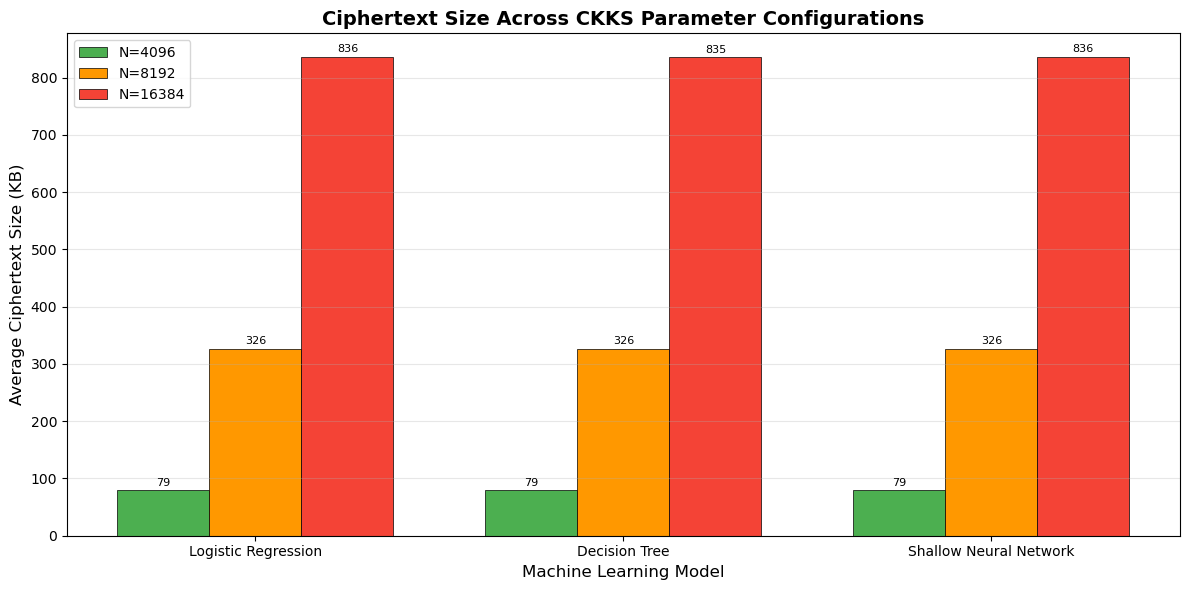

Saved: graph_ciphertext_size.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.25
config_colors = ["#4CAF50", "#FF9800", "#F44336"]

for config_idx in range(1, 4):
    config_data = results_df[results_df["Config"] == config_idx]
    ct_sizes = [config_data[config_data["Model"] == m]["HE_Avg_Ciphertext_Size_Bytes"].values[0] / 1024
                for m in model_names]
    offset = (config_idx - 2) * width
    label = f"N={parameter_configs[config_idx-1]['poly_modulus_degree']}"
    bars = ax.bar(x + offset, ct_sizes, width, label=label, color=config_colors[config_idx-1], edgecolor="black", linewidth=0.5)

    # Add value labels
    for bar, size in zip(bars, ct_sizes):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{size:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Machine Learning Model", fontsize=12)
ax.set_ylabel("Average Ciphertext Size (KB)", fontsize=12)
ax.set_title("Ciphertext Size Across CKKS Parameter Configurations", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graph_ciphertext_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_ciphertext_size.png")

9.5 Trade-Off Analysis: Security vs Performance

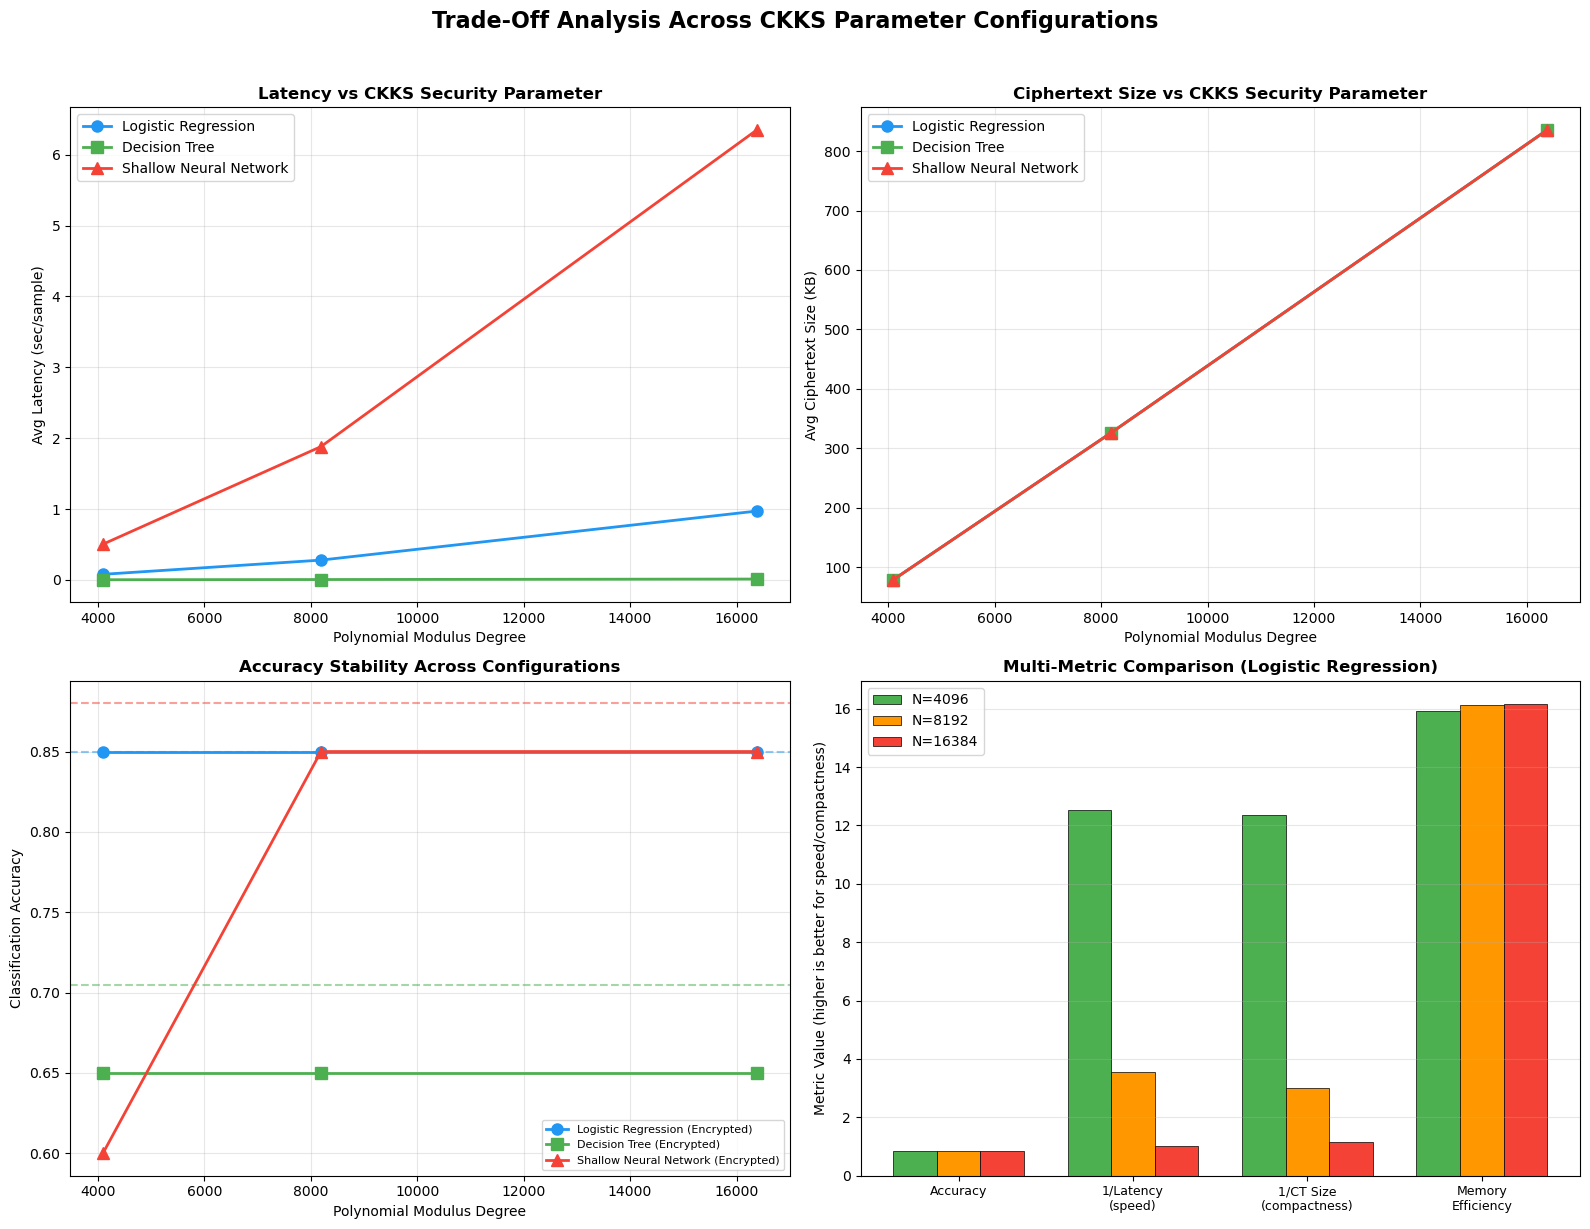

Saved: graph_tradeoff_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Data for Logistic Regression across configs (representative model)
lr_data = results_df[results_df["Model"] == "Logistic Regression"].sort_values("Poly_Modulus_Degree")
poly_degrees = lr_data["Poly_Modulus_Degree"].values
config_labels = [f"N={d}" for d in poly_degrees]

# Top-left: Latency vs Poly Modulus Degree (all models)
ax1 = axes[0, 0]
for model_name, marker, color in zip(model_names, ['o', 's', '^'], ['#2196F3', '#4CAF50', '#F44336']):
    model_data = results_df[results_df["Model"] == model_name].sort_values("Poly_Modulus_Degree")
    ax1.plot(model_data["Poly_Modulus_Degree"], model_data["HE_Avg_Latency_sec"],
             marker=marker, color=color, label=model_name, linewidth=2, markersize=8)
ax1.set_xlabel("Polynomial Modulus Degree")
ax1.set_ylabel("Avg Latency (sec/sample)")
ax1.set_title("Latency vs CKKS Security Parameter", fontweight="bold")
ax1.legend()
ax1.grid(alpha=0.3)

# Top-right: Ciphertext Size vs Poly Modulus Degree
ax2 = axes[0, 1]
for model_name, marker, color in zip(model_names, ['o', 's', '^'], ['#2196F3', '#4CAF50', '#F44336']):
    model_data = results_df[results_df["Model"] == model_name].sort_values("Poly_Modulus_Degree")
    ax2.plot(model_data["Poly_Modulus_Degree"], model_data["HE_Avg_Ciphertext_Size_Bytes"] / 1024,
             marker=marker, color=color, label=model_name, linewidth=2, markersize=8)
ax2.set_xlabel("Polynomial Modulus Degree")
ax2.set_ylabel("Avg Ciphertext Size (KB)")
ax2.set_title("Ciphertext Size vs CKKS Security Parameter", fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.3)

# Bottom-left: Accuracy stability across configs (all models)
ax3 = axes[1, 0]
for model_name, marker, color in zip(model_names, ['o', 's', '^'], ['#2196F3', '#4CAF50', '#F44336']):
    model_data = results_df[results_df["Model"] == model_name].sort_values("Poly_Modulus_Degree")
    ax3.plot(model_data["Poly_Modulus_Degree"], model_data["HE_Accuracy"],
             marker=marker, color=color, label=f"{model_name} (Encrypted)", linewidth=2, markersize=8)
    # Add plaintext reference
    ax3.axhline(y=plaintext_results[model_name]["accuracy"], color=color, linestyle='--', alpha=0.5)
ax3.set_xlabel("Polynomial Modulus Degree")
ax3.set_ylabel("Classification Accuracy")
ax3.set_title("Accuracy Stability Across Configurations", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# Bottom-right: Radar / Multi-metric for LR (normalised)
ax4 = axes[1, 1]
metrics_labels = ["Accuracy", "1/Latency\n(speed)", "1/CT Size\n(compactness)", "Memory\nEfficiency"]
config_colors_2 = ["#4CAF50", "#FF9800", "#F44336"]

for config_idx in range(1, 4):
    config_data = results_df[(results_df["Config"] == config_idx) & (results_df["Model"] == "Logistic Regression")]
    if len(config_data) > 0:
        row = config_data.iloc[0]
        vals = [
            row["HE_Accuracy"],
            1.0 / max(row["HE_Avg_Latency_sec"], 0.001),
            1.0 / max(row["HE_Avg_Ciphertext_Size_Bytes"] / 1e6, 0.001),
            1.0 / max(row["HE_Avg_Memory_MB"], 0.001)
        ]
        # Normalise to 0-1
        vals_norm = [v / max(v, 0.001) for v in vals]
        x_pos = np.arange(len(metrics_labels))
        ax4.bar(x_pos + (config_idx-2)*0.25, vals, width=0.25,
                label=f"N={parameter_configs[config_idx-1]['poly_modulus_degree']}",
                color=config_colors_2[config_idx-1], edgecolor="black", linewidth=0.5)

ax4.set_xticks(np.arange(len(metrics_labels)))
ax4.set_xticklabels(metrics_labels, fontsize=9)
ax4.set_ylabel("Metric Value (higher is better for speed/compactness)")
ax4.set_title("Multi-Metric Comparison (Logistic Regression)", fontweight="bold")
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

plt.suptitle("Trade-Off Analysis Across CKKS Parameter Configurations", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("graph_tradeoff_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_tradeoff_analysis.png")

9.6 Model Comparison Under Encrypted Conditions

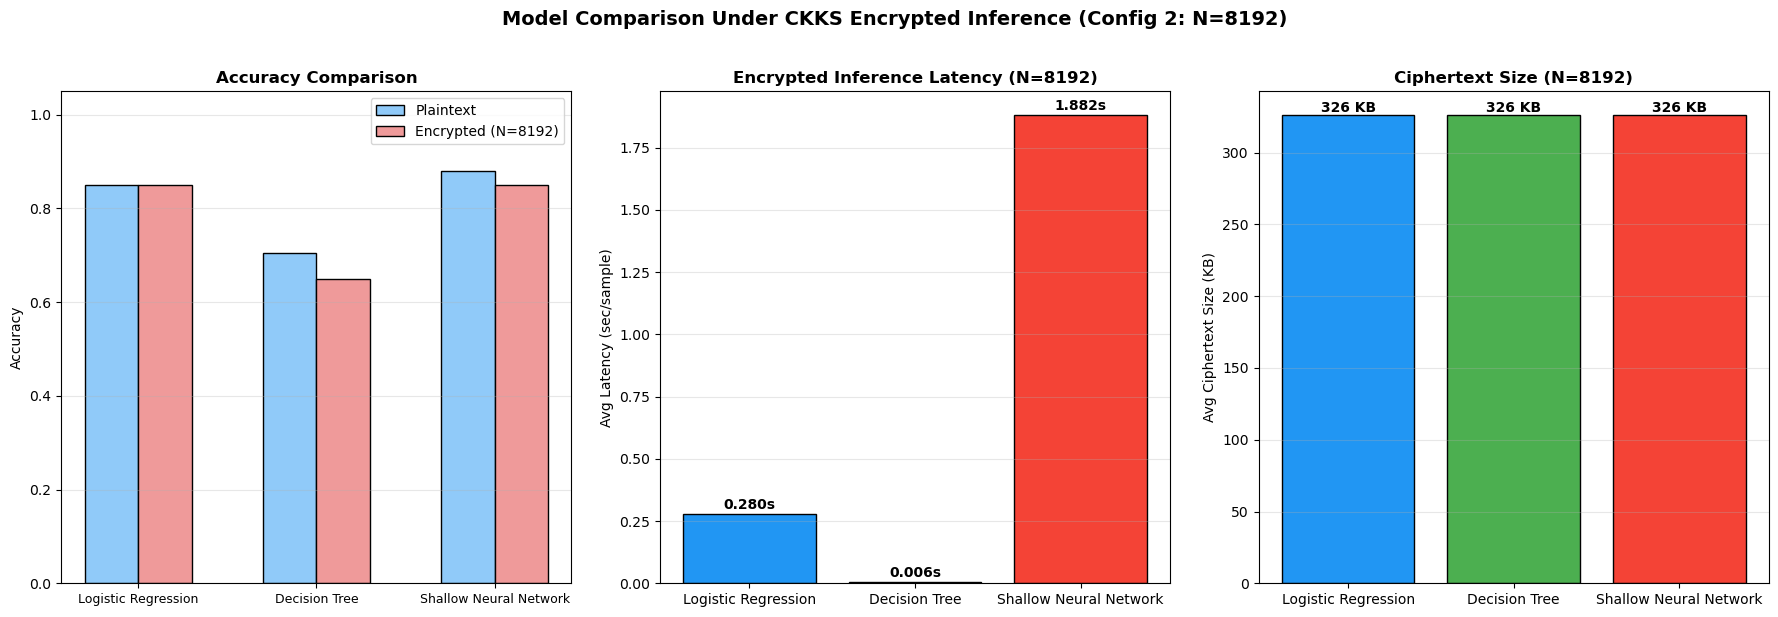

Saved: graph_model_comparison.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = list(models.keys())
model_colors = ['#2196F3', '#4CAF50', '#F44336']

# Use Config 2 (N=8192) as the representative comparison
config2_data = results_df[results_df["Config"] == 2]

# Plot 1: Accuracy
ax1 = axes[0]
plain_acc = [plaintext_results[m]["accuracy"] for m in model_names]
enc_acc = [config2_data[config2_data["Model"] == m]["HE_Accuracy"].values[0] for m in model_names]
x = np.arange(len(model_names))
ax1.bar(x - 0.15, plain_acc, 0.3, label="Plaintext", color="#90CAF9", edgecolor="black")
ax1.bar(x + 0.15, enc_acc, 0.3, label="Encrypted (N=8192)", color="#EF9A9A", edgecolor="black")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy Comparison", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=9)
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(axis="y", alpha=0.3)

# Plot 2: Latency
ax2 = axes[1]
enc_lat = [config2_data[config2_data["Model"] == m]["HE_Avg_Latency_sec"].values[0] for m in model_names]
ax2.bar(model_names, enc_lat, color=model_colors, edgecolor="black")
ax2.set_ylabel("Avg Latency (sec/sample)")
ax2.set_title("Encrypted Inference Latency (N=8192)", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(enc_lat):
    ax2.text(i, v + 0.02, f'{v:.3f}s', ha='center', fontsize=10, fontweight='bold')

# Plot 3: Ciphertext Size
ax3 = axes[2]
enc_ct = [config2_data[config2_data["Model"] == m]["HE_Avg_Ciphertext_Size_Bytes"].values[0] / 1024
          for m in model_names]
ax3.bar(model_names, enc_ct, color=model_colors, edgecolor="black")
ax3.set_ylabel("Avg Ciphertext Size (KB)")
ax3.set_title("Ciphertext Size (N=8192)", fontweight="bold")
ax3.grid(axis="y", alpha=0.3)
for i, v in enumerate(enc_ct):
    ax3.text(i, v + 2, f'{v:.0f} KB', ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Model Comparison Under CKKS Encrypted Inference (Config 2: N=8192)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("graph_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: graph_model_comparison.png")

10. Final Summary and Study Conclusions

In [ ]:
print("=" * 70)
print("STUDY SUMMARY")
print("=" * 70)

print("\n--- Plaintext Baseline ---")
for name in model_names:
    r = plaintext_results[name]
    print(f"  {name}: Accuracy={r['accuracy']:.4f}, Latency={r['latency_sec']:.6f}s, Memory={r['memory_mb']:.4f}MB")

print("\n--- Encrypted Inference (Best Config: N=4096) ---")
best_config = results_df[results_df["Config"] == 1]
for name in model_names:
    r = best_config[best_config["Model"] == name].iloc[0]
    print(f"  {name}: Accuracy={r['HE_Accuracy']:.4f}, Avg Latency={r['HE_Avg_Latency_sec']:.4f}s/sample, CT Size={r['HE_Avg_Ciphertext_Size_Bytes']:.0f} bytes")


STUDY SUMMARY

--- Plaintext Baseline ---
  Logistic Regression: Accuracy=0.8500, Latency=0.000875s, Memory=1.2130MB
  Decision Tree: Accuracy=0.7050, Latency=0.000374s, Memory=0.0329MB
  Shallow Neural Network: Accuracy=0.8800, Latency=0.001135s, Memory=0.0817MB

--- Encrypted Inference (Best Config: N=4096) ---
  Logistic Regression: Accuracy=0.8500, Avg Latency=0.0797s/sample, CT Size=80915 bytes
  Decision Tree: Accuracy=0.6500, Avg Latency=0.0034s/sample, CT Size=80933 bytes
  Shallow Neural Network: Accuracy=0.6000, Avg Latency=0.5047s/sample, CT Size=80900 bytes
